In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, RocCurveDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("stroke_risk_dataset_v2.csv")

In [4]:
df.head()

,age,gender,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,swelling_edema,neck_jaw_pain,excessive_sweating,persistent_cough,nausea_vomiting,chest_discomfort,cold_hands_feet,snoring_sleep_apnea,anxiety_doom,stroke_risk_percentage,at_risk
0,22,Male,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,33.3,0
1,52,Male,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,100.0,1
2,63,Female,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,100.0,1
3,41,Male,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,44.5,0
4,53,Male,0,0,0,0,0,1,1,0,0,0,1,0,1,0,0,84.8,1


In [5]:
df.shape

(35000, 19)

In [6]:
df.columns

Index(['age', 'gender', 'chest_pain', 'high_blood_pressure',
       'irregular_heartbeat', 'shortness_of_breath', 'fatigue_weakness',
       'dizziness', 'swelling_edema', 'neck_jaw_pain', 'excessive_sweating',
       'persistent_cough', 'nausea_vomiting', 'chest_discomfort',
       'cold_hands_feet', 'snoring_sleep_apnea', 'anxiety_doom',
       'stroke_risk_percentage', 'at_risk'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     35000 non-null  int64  
 1   gender                  35000 non-null  object 
 2   chest_pain              35000 non-null  int64  
 3   high_blood_pressure     35000 non-null  int64  
 4   irregular_heartbeat     35000 non-null  int64  
 5   shortness_of_breath     35000 non-null  int64  
 6   fatigue_weakness        35000 non-null  int64  
 7   dizziness               35000 non-null  int64  
 8   swelling_edema          35000 non-null  int64  
 9   neck_jaw_pain           35000 non-null  int64  
 10  excessive_sweating      35000 non-null  int64  
 11  persistent_cough        35000 non-null  int64  
 12  nausea_vomiting         35000 non-null  int64  
 13  chest_discomfort        35000 non-null  int64  
 14  cold_hands_feet         35000 non-null

In [8]:
df.isnull().sum()

age                       0
gender                    0
chest_pain                0
high_blood_pressure       0
irregular_heartbeat       0
shortness_of_breath       0
fatigue_weakness          0
dizziness                 0
swelling_edema            0
neck_jaw_pain             0
excessive_sweating        0
persistent_cough          0
nausea_vomiting           0
chest_discomfort          0
cold_hands_feet           0
snoring_sleep_apnea       0
anxiety_doom              0
stroke_risk_percentage    0
at_risk                   0
dtype: int64

In [33]:
df.describe()

,age,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,swelling_edema,neck_jaw_pain,excessive_sweating,persistent_cough,nausea_vomiting,chest_discomfort,cold_hands_feet,snoring_sleep_apnea,anxiety_doom,stroke_risk_percentage,at_risk
count,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000
mean,38.630171,0.145857,0.251914,0.098457,0.190057,0.244543,0.190686,0.145943,0.099514,0.097514,0.105971,0.097543,0.143771,0.194571,0.147086,0.098543,44.484054,0.368200
std,11.564128,0.352968,0.434118,0.297936,0.392352,0.429822,0.392847,0.353054,0.299356,0.296661,0.307805,0.296700,0.350863,0.395876,0.354196,0.298052,29.894012,0.482323
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,0.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.900000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,38.700000,0.000000
75%,46.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.500000,1.000000
max,86.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000


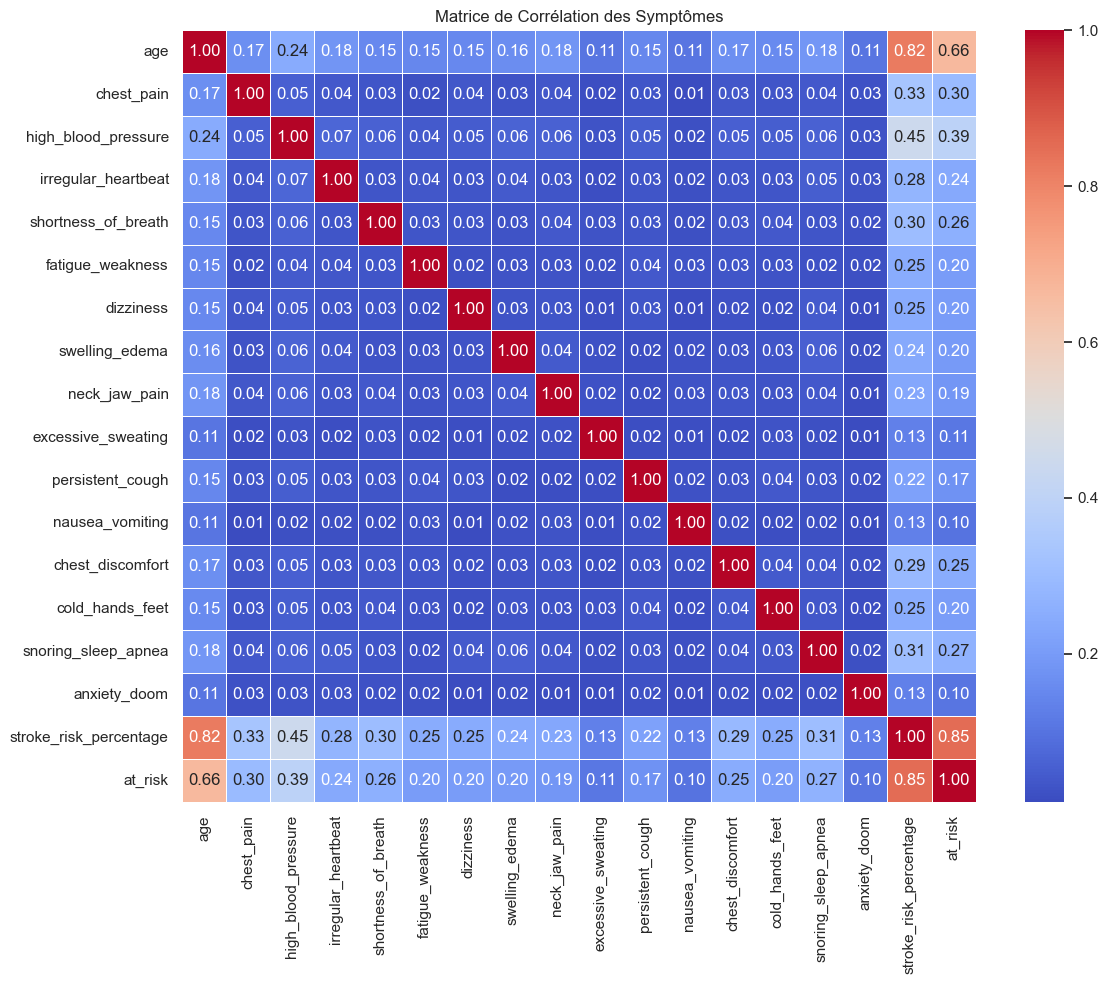

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de Corrélation des Symptômes')
plt.tight_layout()
plt.show()

In [10]:
X = df.drop(columns=['age', 'gender', 'stroke_risk_percentage', 'at_risk'], errors='ignore')
y = df['at_risk']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [16]:
print("acc :", acc)

acc : 0.863


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

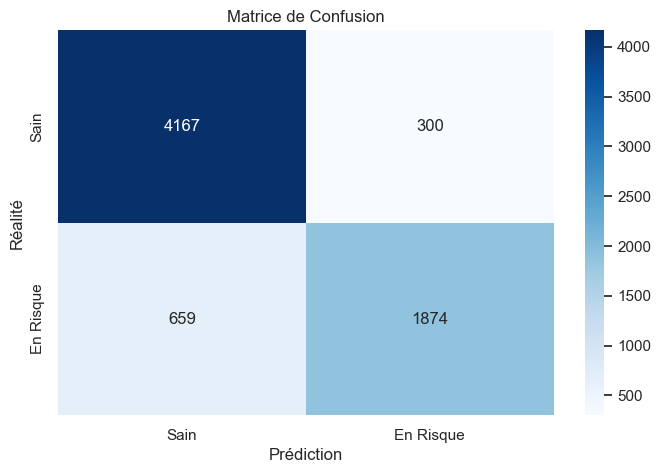

In [32]:
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sain', 'En Risque'], yticklabels=['Sain', 'En Risque'])
plt.title("Matrice de Confusion")
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

<Figure size 800x500 with 0 Axes>

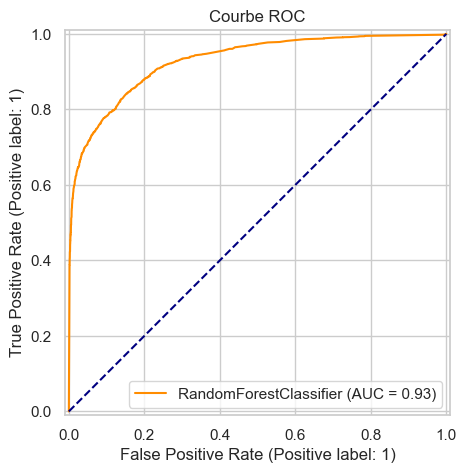

In [37]:
plt.figure()
RocCurveDisplay.from_estimator(model, X_test, y_test, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Courbe ROC')
plt.grid(True)
plt.show()

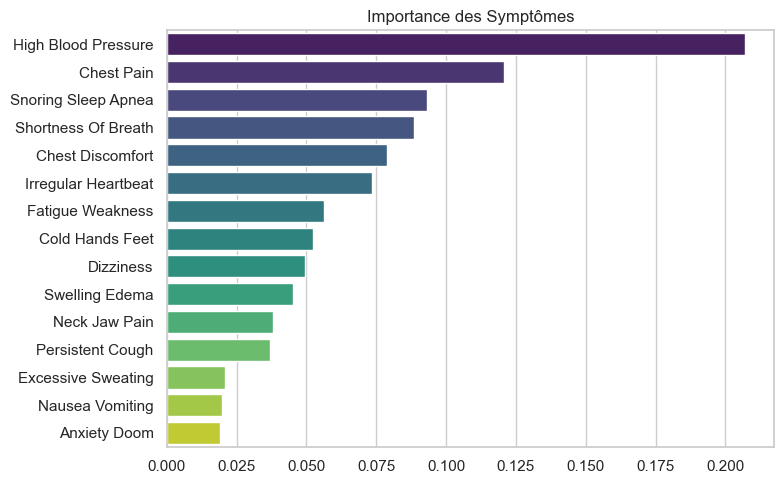

In [38]:
plt.figure()
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features_names = [list(X.columns)[i].replace('_', ' ').title() for i in indices]
sns.barplot(x=importances[indices], y=features_names, palette="viridis")
plt.title('Importance des Symptômes')
plt.tight_layout()
plt.show()

In [39]:
symptoms_multilang = {
    'chest_pain': {'en': 'Chest Pain', 'fr': 'Douleur thoracique', 'dar': 'حريق أو نغزة ف الصدر'},
    'high_blood_pressure': {'en': 'High Blood Pressure', 'fr': 'Tension artérielle élevée', 'dar': 'طونسيون طالع'},
    'irregular_heartbeat': {'en': 'Irregular Heartbeat', 'fr': 'Battements de coeur irréguliers', 'dar': 'دقات قلب مامتناظمينش'},
    'shortness_of_breath': {'en': 'Shortness of Breath', 'fr': 'Essoufflement', 'dar': 'ضيق التنفس'},
    'fatigue_weakness': {'en': 'Fatigue or Weakness', 'fr': 'Fatigue ou faiblesse générale', 'dar': 'عيا وفشلة ف الذات'},
    'dizziness': {'en': 'Dizziness / Vertigo', 'fr': 'Étourdissements / Vertiges', 'dar': 'الدوخة أو السخفة'},
    'swelling_edema': {'en': 'Swelling / Edema', 'fr': 'Gonflement / Œdème', 'dar': 'النفورية ف الرجلين أو اليدين'},
    'neck_jaw_pain': {'en': 'Neck or Jaw Pain', 'fr': 'Douleur au cou/mâchoire', 'dar': 'حريق ف العنق أو الفك'},
    'excessive_sweating': {'en': 'Excessive Sweating', 'fr': 'Transpiration excessive', 'dar': 'التعرق بكثرة بلا مجهود'},
    'persistent_cough': {'en': 'Persistent Cough', 'fr': 'Toux persistante', 'dar': 'كحبة مابغاتش تفوت'},
    'nausea_vomiting': {'en': 'Nausea or Vomiting', 'fr': 'Nausées ou vomissements', 'dar': 'الردان أو الدوخة د المعدة'},
    'chest_discomfort': {'en': 'Chest Discomfort', 'fr': 'Gêne dans la poitrine', 'dar': 'الضيم أو ثقل على الصدر'},
    'cold_hands_feet': {'en': 'Cold Hands or Feet', 'fr': 'Mains ou pieds froids', 'dar': 'البرودية ف اليدين والرجلين'},
    'snoring_sleep_apnea': {'en': 'Snoring / Sleep Apnea', 'fr': 'Ronflement / Apnée du sommeil', 'dar': 'الشخير وتقطع النفس'},
    'anxiety_doom': {'en': 'Intense Anxiety', 'fr': 'Anxiété intense', 'dar': 'خوف وقلق شديد مفاجئ'}
}

In [41]:
def stroke_checker_chatbot():
    print(" [Chatbot]: السلام عليكم! أنا نظام ذكي لتقييم خطر الإصابة بالجلطة الدماغية.")
    print(" [Chatbot]: Bonjour! Je suis un système intelligent pour évaluer le risque d'AVC.")
    print(" [Chatbot]: Hello! I am an AI system to evaluate stroke risk.\n")
    print(" Répondez par / Answer with: (yes) ou/or (no). [Tapez 'quitter' pour sortir]")
    print("-" * 70 + "\n")

In [45]:
symptoms_to_ask = list(X.columns)
user_answers = {}
quitted = False

In [ ]:
for symptom in symptoms_to_ask:
        lang_dict = symptoms_multilang.get(symptom)
        if lang_dict:
            question_text = f"🔹 FR: {lang_dict['fr']}\n🔹 EN: {lang_dict['en']}\n🔹 AR: {lang_dict['dar']}"
        else:
            question_text = symptom.replace('_', ' ').title()
            
        while True:
            print(question_text)
            user_input = input(" [yes / no]: ").strip().lower()
            print()
            
            if user_input == 'quitter':
                print("\n [Chatbot]: الله يجيب الشفاء! Bon rétablissement! Bye.")
                quitted = True
                break
            if user_input in ['yes', 'oui', 'y', 'o', 'اه', 'نعم']:
                user_answers[symptom] = [1]
                break
            elif user_input in ['no', 'non', 'n', 'لا', 'لا لا']:
                user_answers[symptom] = [0]
                break
            else:
                print(" Invalid answer! (yes/oui/اه) ou/or (no/non/لا).\n")
        if quitted:
            break
if not quitted:
        user_df = pd.DataFrame(user_answers)
        prediction = model.predict(user_df)[0]
        probability = model.predict_proba(user_df)[0][prediction] * 100
        
        print("\n" + "="*60)
        print("RÉSULTAT DE L'ANALYSE / ANALYTICAL RESULT :")
        print("="*60)
        
        if prediction == 1:
            print(f" تحذير (At Risk): الموديل يتوقع وجود خطر الإصابة بنسبة يقين {probability:.1f}%.")
            print("🇫🇷 Le modèle estime que vous êtes EN SITUATION DE RISQUE.")
            print("🇬🇧 The model predicts that you are AT RISK.")
        else:
            print(f" الحمد لله (Safe): الموديل يتوقع أنك سليم بنسبة يقين {probability:.1f}%.")
            print("🇫🇷 Le modèle estime que vous êtes SAIN (Pas de risque).")
            print("🇬🇧 The model predicts that you are SAFE.")
        print("="*60)

🔹 FR: Douleur thoracique
🔹 EN: Chest Pain
🔹 AR: حريق أو نغزة ف الصدر
